# Data Wrangling

This notebook prepares the dataset for modeling by transforming cleaned relational tables into an analysis-ready format.

The process includes:
- Data validation
- Feature engineering
- Building a monthly-level master dataset
- Correlation analysis and feature selection

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data from Database

We load the cleaned tables from the SQLite database created in Milestone 1.

In [3]:
conn = sqlite3.connect("../humanitarian.db")

crises_df    = pd.read_sql("SELECT * FROM crises",            conn)
monthly_df   = pd.read_sql("SELECT * FROM monthly_coverage",  conn)
outlet_df    = pd.read_sql("SELECT * FROM coverage_by_outlet",conn)
framing_df   = pd.read_sql("SELECT * FROM framing",           conn)
sentiment_df = pd.read_sql("SELECT * FROM sentiment",         conn)
victim_df    = pd.read_sql("SELECT * FROM victim_causor",      conn)

## Data Validation

We perform quick checks to ensure data consistency before transformation.

In [4]:
tables = {
    "crises":    crises_df,
    "monthly":   monthly_df,
    "outlet":    outlet_df,
    "framing":   framing_df,
    "sentiment": sentiment_df,
    "victim":    victim_df
}

for name, df in tables.items():
    print(f"{name} shape:", df.shape)
    print(f"{name} duplicates:", df.duplicated().sum())
    print("-" * 40)

crises shape: (10, 10)
crises duplicates: 0
----------------------------------------
monthly shape: (734, 4)
monthly duplicates: 0
----------------------------------------
outlet shape: (403, 7)
outlet duplicates: 0
----------------------------------------
framing shape: (471, 7)
framing duplicates: 0
----------------------------------------
sentiment shape: (430, 7)
sentiment duplicates: 0
----------------------------------------
victim shape: (348, 7)
victim duplicates: 0
----------------------------------------


In [5]:
# check missing values
for name, df in tables.items():
    nulls = df.isnull().sum().sum()
    print(f"{name}: {nulls} missing values")

crises: 0 missing values
monthly: 0 missing values
outlet: 0 missing values
framing: 0 missing values
sentiment: 0 missing values
victim: 0 missing values


## Why Monthly-Level?

The monthly coverage table has 734 rows (one per crisis per month). By building the
master table at the monthly level we also capture how coverage changes over time within
each crisis, which was one of the clearest patterns from our EDA.

# Feature Engineering

## Time Features

We attach crisis start dates to the monthly table and compute how many months
have passed since each crisis began. This captures the coverage decay pattern
observed in EDA, where attention spikes at onset and drops sharply afterward.

In [6]:
monthly = monthly_df.copy()
monthly["year_month"] = pd.to_datetime(monthly["year_month"])

crisis_meta = crises_df[["crisis_id", "crisis_name", "start_date",
                          "fund_required", "people_affected", "crisis_days"]].copy()
crisis_meta["start_date"] = pd.to_datetime(crisis_meta["start_date"])

monthly = monthly.merge(crisis_meta, on="crisis_id", how="left")

# how many months since the crisis started
monthly["months_since_start"] = (
    (monthly["year_month"].dt.year  - monthly["start_date"].dt.year) * 12 +
    (monthly["year_month"].dt.month - monthly["start_date"].dt.month)
).clip(lower=0)

# onset flag -- first 3 months is where most of the spike happens
monthly["is_onset"] = (monthly["months_since_start"] <= 3).astype(int)

monthly[["crisis_name", "year_month", "coverage_count",
         "months_since_start", "is_onset"]].head(10)

,crisis_name,year_month,coverage_count,months_since_start,is_onset
0,Afghanistan,2021-08-01,3306,0,1
1,Afghanistan,2021-09-01,981,1,1
2,Afghanistan,2021-10-01,305,2,1
3,Afghanistan,2021-11-01,212,3,1
4,Afghanistan,2021-12-01,156,4,0
5,Afghanistan,2022-01-01,100,5,0
6,Afghanistan,2022-02-01,79,6,0
7,Afghanistan,2022-03-01,59,7,0
8,Afghanistan,2022-04-01,50,8,0
9,Afghanistan,2022-05-01,46,9,0


In [7]:
# sanity check
assert (monthly["months_since_start"] >= 0).all(), "Negative months_since_start found"
print("months_since_start range:", monthly["months_since_start"].min(),
      "to", monthly["months_since_start"].max())
print("Onset months:", monthly["is_onset"].sum())

months_since_start range: 0 to 187
Onset months: 38


Coverage counts are heavily skewed -- Gaza and Ukraine have months above 7000 articles
while most crises sit under 200. We log-transform the target to reduce this skew.

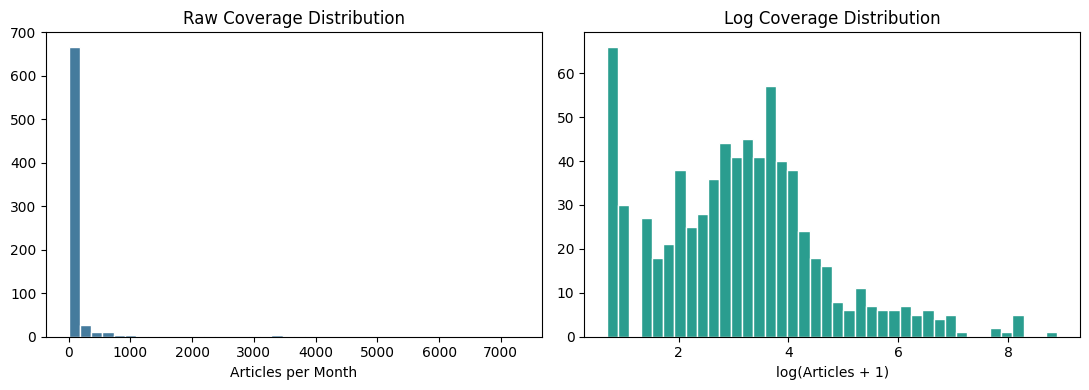

In [8]:
monthly["log_coverage"] = np.log1p(monthly["coverage_count"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(monthly["coverage_count"], bins=40, color="#457B9D", edgecolor="white")
axes[0].set_title("Raw Coverage Distribution")
axes[0].set_xlabel("Articles per Month")

axes[1].hist(monthly["log_coverage"], bins=40, color="#2A9D8F", edgecolor="white")
axes[1].set_title("Log Coverage Distribution")
axes[1].set_xlabel("log(Articles + 1)")

plt.tight_layout()
plt.show()

## Framing Ratios

We calculate the proportion of each framing type per crisis to identify dominant narratives.

Note: framing data is only available for Gaza and Ukraine. These columns will be 0
for all other crises, which we acknowledge as a data limitation.

In [9]:
framing_counts = framing_df.groupby(["crisis_id", "framing_type"])["raw_count"].sum().reset_index()

total_mentions = framing_counts.groupby("crisis_id")["raw_count"].sum().reset_index()
total_mentions.rename(columns={"raw_count": "total_raw_count"}, inplace=True)

framing_counts = framing_counts.merge(total_mentions, on="crisis_id")
framing_counts["framing_ratio"] = framing_counts["raw_count"] / framing_counts["total_raw_count"]

framing_counts.head()

,crisis_id,framing_type,raw_count,total_raw_count,framing_ratio
0,5,economic,660,45128,0.014625
1,5,geopolitical,9598,45128,0.212684
2,5,humanitarian,18104,45128,0.401170
3,5,legal,1208,45128,0.026768
4,5,military,11456,45128,0.253856


In [10]:
framing_pivot = framing_counts.pivot(
    index="crisis_id", columns="framing_type", values="framing_ratio"
).fillna(0)

framing_pivot.columns = [f"framing_ratio_{col}" for col in framing_pivot.columns]
framing_pivot = framing_pivot.reset_index()

framing_pivot.head()

,crisis_id,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian,framing_ratio_legal,framing_ratio_military,framing_ratio_other
0,5,0.014625,0.212684,0.401170,0.026768,0.253856,0.090897
1,9,0.038667,0.324609,0.239519,0.015099,0.326800,0.055306


## Outlet Concentration

We compute the percentage of coverage contributed by the top 3 outlets per crisis.

This helps us understand whether media coverage is:
- **Concentrated** (few outlets dominate coverage)
- **Distributed** (many outlets contribute more evenly)

In [11]:
outlet_counts = outlet_df.groupby(["crisis_id", "outlet_name"])["coverage_count"].sum().reset_index()

def top3_percentage(df):
    df_sorted = df.sort_values(by="coverage_count", ascending=False)
    top3_sum  = df_sorted.head(3)["coverage_count"].sum()
    total_sum = df_sorted["coverage_count"].sum()
    return top3_sum / total_sum if total_sum > 0 else 0

top3_list = []
for cid, group in outlet_counts.groupby("crisis_id"):
    top3_list.append({
        "crisis_id":         cid,
        "top3_outlet_ratio": top3_percentage(group)
    })

top3_outlet_df = pd.DataFrame(top3_list)
top3_outlet_df.head()

,crisis_id,top3_outlet_ratio
0,1,0.211033
1,2,0.355301
2,3,0.453797
3,4,0.551952
4,5,0.173983


## Coverage Decay Rate

From EDA we saw that coverage drops quickly after the onset period. We quantify this
per crisis as the ratio of average post-onset coverage to average onset coverage.

A low value means coverage collapsed after the initial spike.
A high value means the crisis maintained sustained attention.

In [12]:
decay_rows = []

for cid, group in monthly.groupby("crisis_id"):
    onset      = group[group["months_since_start"] <= 3]["coverage_count"].mean()
    post_onset = group[group["months_since_start"] >  3]["coverage_count"].mean()

    if pd.isna(onset) or onset == 0:
        ratio = 0
    elif pd.isna(post_onset):
        ratio = 1
    else:
        ratio = post_onset / onset

    decay_rows.append({"crisis_id": cid, "post_onset_ratio": round(ratio, 4)})

decay_df = pd.DataFrame(decay_rows)
decay_df

,crisis_id,post_onset_ratio
0,1,0.0747
1,2,0.9899
2,3,0.8675
3,4,0.2102
4,5,0.3153
5,6,0.1751
6,7,0.2932
7,8,1.2177
8,9,0.1663
9,10,0.7283


## Merge Features into Master Table

We now combine all engineered features into a single monthly-level master dataset.

Each row represents one crisis in one month. Crisis-level features (framing ratios,
outlet concentration, decay rate) are repeated across all months for that crisis.

Missing framing values are filled with 0 for crises without framing data.

In [13]:
master_df = monthly.copy()

master_df = master_df.merge(top3_outlet_df, on="crisis_id", how="left")
master_df = master_df.merge(framing_pivot,  on="crisis_id", how="left")
master_df = master_df.merge(decay_df,       on="crisis_id", how="left")

framing_cols = [c for c in master_df.columns if c.startswith("framing_ratio")]
master_df[framing_cols] = master_df[framing_cols].fillna(0)

print("Master table shape:", master_df.shape)
master_df.head()

Master table shape: (734, 20)


,monthly_id,crisis_id,year_month,coverage_count,crisis_name,start_date,fund_required,people_affected,crisis_days,months_since_start,is_onset,log_coverage,top3_outlet_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian,framing_ratio_legal,framing_ratio_military,framing_ratio_other,post_onset_ratio
0,1,1,2021-08-01,3306,Afghanistan,2021-08-01,3.04,22.9,1287,0,1,8.103797,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
1,2,1,2021-09-01,981,Afghanistan,2021-08-01,3.04,22.9,1287,1,1,6.889591,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
2,3,1,2021-10-01,305,Afghanistan,2021-08-01,3.04,22.9,1287,2,1,5.723585,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
3,4,1,2021-11-01,212,Afghanistan,2021-08-01,3.04,22.9,1287,3,1,5.361292,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
4,5,1,2021-12-01,156,Afghanistan,2021-08-01,3.04,22.9,1287,4,0,5.056246,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747


## Feature Overview

The final master dataset includes:

**Target:**
- `log_coverage` -- log-transformed monthly article count (used as modeling target)
- `coverage_count` -- raw count kept for reference

**Time features (new):**
- `months_since_start` -- how far into the crisis this month falls
- `is_onset` -- 1 if within first 3 months, 0 otherwise

**Crisis severity:**
- `fund_required`, `people_affected`, `crisis_days`

**Engineered features:**
- `top3_outlet_ratio` -- share of coverage from top 3 outlets
- `post_onset_ratio` -- sustained attention after the onset spike
- `framing_ratio_*` -- narrative framing mix (Gaza and Ukraine only)

In [14]:
master_df.head()

,monthly_id,crisis_id,year_month,coverage_count,crisis_name,start_date,fund_required,people_affected,crisis_days,months_since_start,is_onset,log_coverage,top3_outlet_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian,framing_ratio_legal,framing_ratio_military,framing_ratio_other,post_onset_ratio
0,1,1,2021-08-01,3306,Afghanistan,2021-08-01,3.04,22.9,1287,0,1,8.103797,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
1,2,1,2021-09-01,981,Afghanistan,2021-08-01,3.04,22.9,1287,1,1,6.889591,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
2,3,1,2021-10-01,305,Afghanistan,2021-08-01,3.04,22.9,1287,2,1,5.723585,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
3,4,1,2021-11-01,212,Afghanistan,2021-08-01,3.04,22.9,1287,3,1,5.361292,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747
4,5,1,2021-12-01,156,Afghanistan,2021-08-01,3.04,22.9,1287,4,0,5.056246,0.211033,0.0,0.0,0.0,0.0,0.0,0.0,0.0747


## Correlation Analysis

We analyze relationships between numerical features to understand potential drivers
of media coverage and to spot redundant features before modeling.

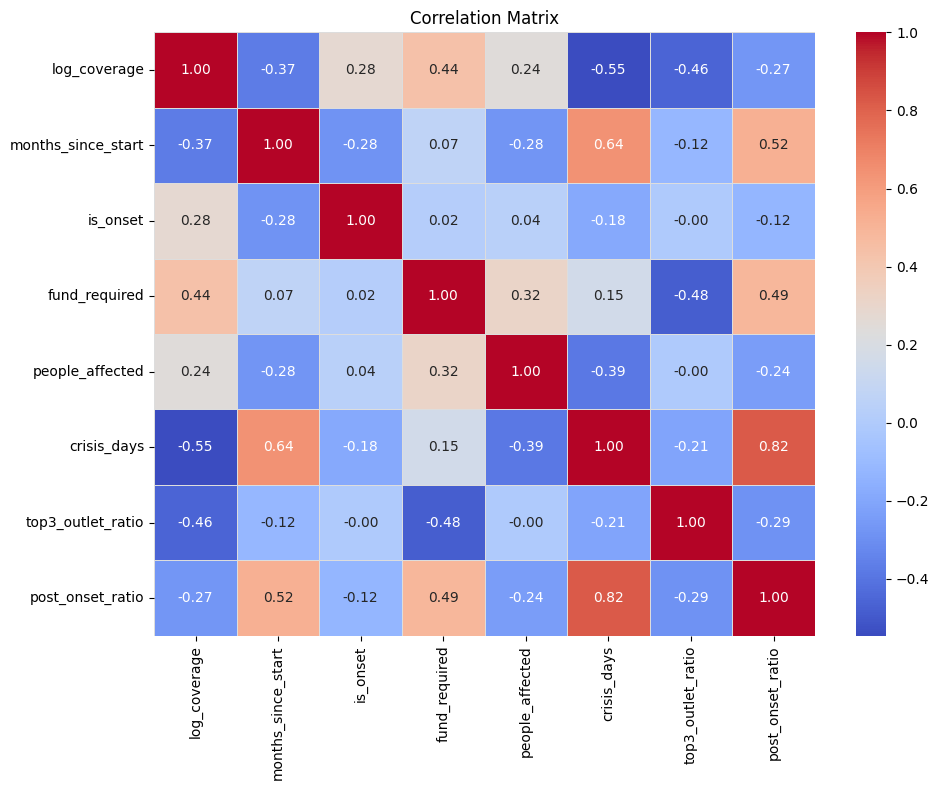

In [15]:
numeric_cols = [
    "log_coverage", "months_since_start", "is_onset",
    "fund_required", "people_affected", "crisis_days",
    "top3_outlet_ratio", "post_onset_ratio"
]

corr_matrix = master_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.4, linecolor="#ddd")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

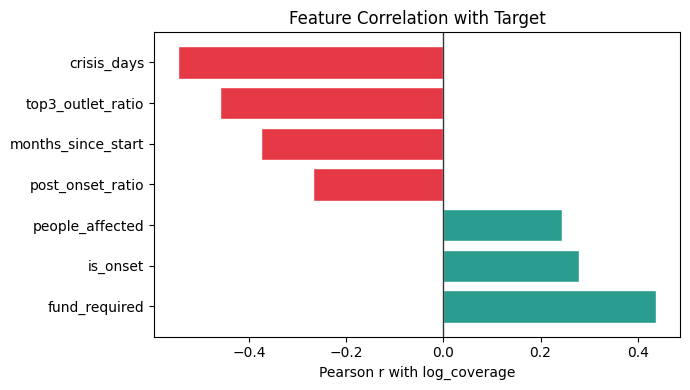

                    log_coverage
fund_required              0.438
is_onset                   0.279
people_affected            0.243
post_onset_ratio          -0.269
months_since_start        -0.374
top3_outlet_ratio         -0.460
crisis_days               -0.545


In [16]:
# correlation with target specifically
target_corr = corr_matrix[["log_coverage"]].drop("log_coverage").sort_values(
    "log_coverage", ascending=False
)

colors = ["#2A9D8F" if v > 0 else "#E63946" for v in target_corr["log_coverage"]]

plt.figure(figsize=(7, 4))
plt.barh(target_corr.index, target_corr["log_coverage"], color=colors, edgecolor="white")
plt.axvline(0, color="#333", linewidth=1)
plt.xlabel("Pearson r with log_coverage")
plt.title("Feature Correlation with Target")
plt.tight_layout()
plt.show()

print(target_corr.round(3))

**Observations:**

- `fund_required` has the strongest positive correlation with log coverage (r = 0.44) --
  crises with larger funding needs tend to receive more monthly attention.
- `crisis_days` is the strongest negative predictor (r = -0.55) -- longer-running crises
  receive less coverage per month, likely because media attention decays over time.
- `months_since_start` is also strongly negative (r = -0.37) -- coverage drops as the
  crisis ages, consistent with the episodic pattern seen in EDA.
- `top3_outlet_ratio` is negative (r = -0.46) -- crises dominated by few outlets
  tend to have lower monthly counts.
- `is_onset` is positive (r = 0.28) -- onset months do receive more coverage on average.
- Severity metrics like `people_affected` show only weak positive correlation (r = 0.24),
  confirming that humanitarian scale does not strongly predict media attention.

## Feature Selection

Based on correlation analysis:

- We retain `months_since_start` and `is_onset` as the strongest predictors
- We keep severity metrics despite weak correlation -- they add crisis-level context
- We keep `top3_outlet_ratio` and `post_onset_ratio` as our main engineered features
- We keep humanitarian, geopolitical, and economic framing ratios
- We drop `framing_ratio_legal`, `framing_ratio_military`, `framing_ratio_other` due to
  high multicollinearity with the other framing columns

In [17]:
model_df = master_df[[
    "crisis_id",
    "crisis_name",
    "year_month",
    "coverage_count",
    "log_coverage",
    "months_since_start",
    "is_onset",
    "fund_required",
    "people_affected",
    "crisis_days",
    "top3_outlet_ratio",
    "post_onset_ratio",
    "framing_ratio_economic",
    "framing_ratio_geopolitical",
    "framing_ratio_humanitarian"
]].copy()

model_df.head()

,crisis_id,crisis_name,year_month,coverage_count,log_coverage,months_since_start,is_onset,fund_required,people_affected,crisis_days,top3_outlet_ratio,post_onset_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
0,1,Afghanistan,2021-08-01,3306,8.103797,0,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
1,1,Afghanistan,2021-09-01,981,6.889591,1,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
2,1,Afghanistan,2021-10-01,305,5.723585,2,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
3,1,Afghanistan,2021-11-01,212,5.361292,3,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
4,1,Afghanistan,2021-12-01,156,5.056246,4,0,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0


## Final Data Validation

Before saving, we verify:
- No missing values remain
- Data types are correct
- Dataset is ready for modeling

In [18]:
print("Shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())

Shape: (734, 15)

Missing values:
crisis_id                     0
crisis_name                   0
year_month                    0
coverage_count                0
log_coverage                  0
months_since_start            0
is_onset                      0
fund_required                 0
people_affected               0
crisis_days                   0
top3_outlet_ratio             0
post_onset_ratio              0
framing_ratio_economic        0
framing_ratio_geopolitical    0
framing_ratio_humanitarian    0
dtype: int64


In [19]:
print(model_df.dtypes)

crisis_id                              int64
crisis_name                           object
year_month                    datetime64[ns]
coverage_count                         int64
log_coverage                         float64
months_since_start                     int32
is_onset                               int64
fund_required                        float64
people_affected                      float64
crisis_days                            int64
top3_outlet_ratio                    float64
post_onset_ratio                     float64
framing_ratio_economic               float64
framing_ratio_geopolitical           float64
framing_ratio_humanitarian           float64
dtype: object


## Saving Clean Dataset

The final dataset is saved to ensure reproducibility and separation between
wrangling and modeling stages.

In [20]:
# path relative to this notebook's location
processed_dir = os.path.join(os.path.dirname(os.path.abspath("data_wrangling.ipynb")),
                             "..", "..", "data", "processed")
processed_dir = os.path.normpath(processed_dir)
os.makedirs(processed_dir, exist_ok=True)

save_path = os.path.join(processed_dir, "monthly_model_data.csv")
model_df.to_csv(save_path, index=False)
model_df.to_sql("monthly_model_data", conn, if_exists="replace", index=False)

print("Saved to:", save_path)
print("Rows:", model_df.shape[0])

Saved to: c:\Users\ashri\Documents\IDS_final\IDS_Project\data\processed\monthly_model_data.csv
Rows: 734


## Data Wrangling Summary

In this stage, raw data was transformed into a structured dataset ready for modeling.

### Steps Completed:
- Data loading and validation
- Rebuilt master table at the monthly level (734 rows vs 10 previously)
- Feature engineering:
  - `months_since_start` and `is_onset` from monthly timestamps
  - `log_coverage` to reduce skew in the target variable
  - Framing ratios per crisis
  - Outlet concentration (top3_outlet_ratio)
  - Coverage decay rate (post_onset_ratio)
- Merging into a monthly-level master dataset
- Handling missing framing values with justified zero-fill
- Correlation analysis
- Feature selection
- Final dataset saved

---

### Key Insights:
- Coverage decay over time is the strongest pattern in the data
- The onset period (first 3 months) drives most of the variance in monthly counts
- Severity metrics remain weak predictors even at the monthly level
- Outlet concentration and framing may explain residual variation

---

### Next Step:
The cleaned dataset will be used in `data_modeling.ipynb` to build and evaluate
regression models that explain monthly media attention.